In [286]:
from os.path import split

from pandas.core.common import random_state
# !pip install pandas
# !pip install scikit-learn
# !pip install seaborn
# !pip install tensorflow

In [38]:
import pandas as pd
import numpy as np

housing_ds = pd.read_csv('C:/Users/chris/Desktop/model optimization/USA Housing Dataset.csv', delimiter=',')
housing_ds.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-09 00:00:00,376000.0,3.0,2.00,1340,1384,3.0,0,0,3,1340,0,2008,0,9245-9249 Fremont Ave N,Seattle,WA 98103,USA
1,2014-05-09 00:00:00,800000.0,4.0,3.25,3540,159430,2.0,0,0,3,3540,0,2007,0,33001 NE 24th St,Carnation,WA 98014,USA
2,2014-05-09 00:00:00,2238888.0,5.0,6.50,7270,130017,2.0,0,0,3,6420,850,2010,0,7070 270th Pl SE,Issaquah,WA 98029,USA
3,2014-05-09 00:00:00,324000.0,3.0,2.25,998,904,2.0,0,0,3,798,200,2007,0,820 NW 95th St,Seattle,WA 98117,USA
4,2014-05-10 00:00:00,549900.0,5.0,2.75,3060,7015,1.0,0,0,5,1600,1460,1979,0,10834 31st Ave SW,Seattle,WA 98146,USA


In [39]:
#Finding NaNs
print(f"NaNs in the dataset: \n{housing_ds.isna().sum()}")

NaNs in the dataset: 
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64


In [40]:
#changing structure of columns:  yr_renovated, sqft_basement
#yr_renovated -> renovated (boolean) & renovation_yr (if renovated then yr_renovated, else yr_built).
#sqft_basement -> has_basement (boolean)
#for better data representation and machine learning application later on

#list initiation per new column to be added
renovated = []
renovation_yr = []
has_basement = []
month = []

#rule-based filling of the lists, as stated in the first comment
for i in range(len(housing_ds)):
    if housing_ds['yr_renovated'][i] == 0:
        renovated.append('0')
        renovation_yr.append(housing_ds["yr_built"][i])
    else:
        renovated.append('1')
        renovation_yr.append(housing_ds["yr_renovated"][i])
    if housing_ds["sqft_basement"][i] == 0:
        has_basement.append('0')
    else:
        has_basement.append('1')
housing_ds["renovated"] = renovated
housing_ds["renovation_yr"] = renovation_yr
housing_ds["has_basement"] = has_basement

#dropping irrelevant columns, and country column as well, since it's always USA
# housing_ds.drop(columns=["yr_renovated","sqft_basement","country"],inplace=True)
# columns to be ignored: ["yr_renovated","sqft_basement","country"]

housing_ds["date"] = pd.to_datetime(housing_ds["date"])

#adding month and day column
#all the dataset is for 2014, so no year column will be added
housing_ds["month"] = housing_ds["date"].dt.month
housing_ds["day"] = housing_ds["date"].dt.day



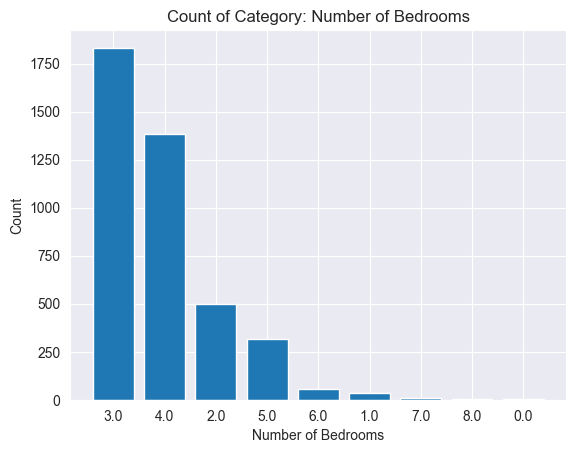

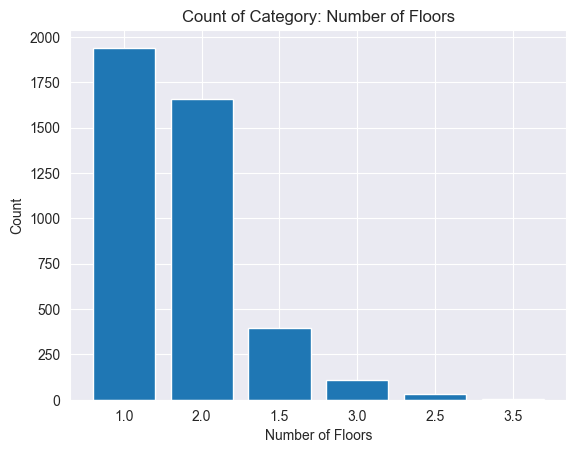

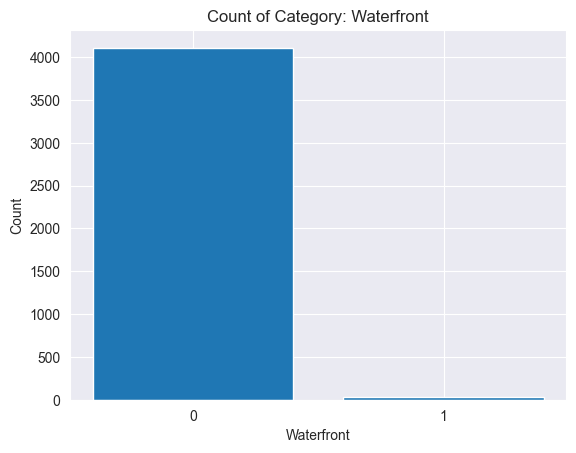

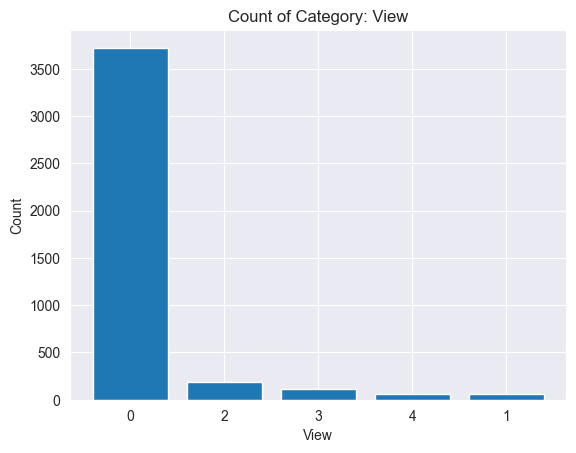

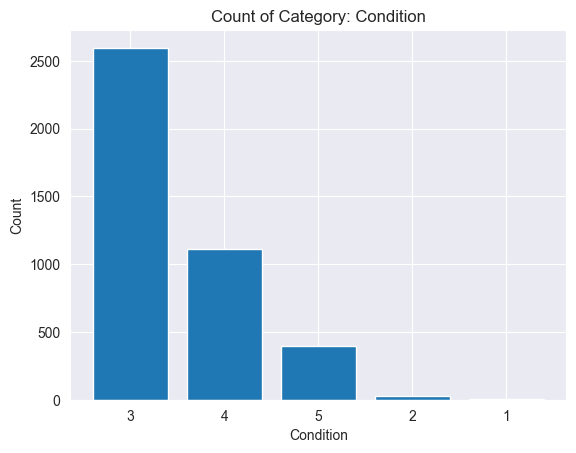

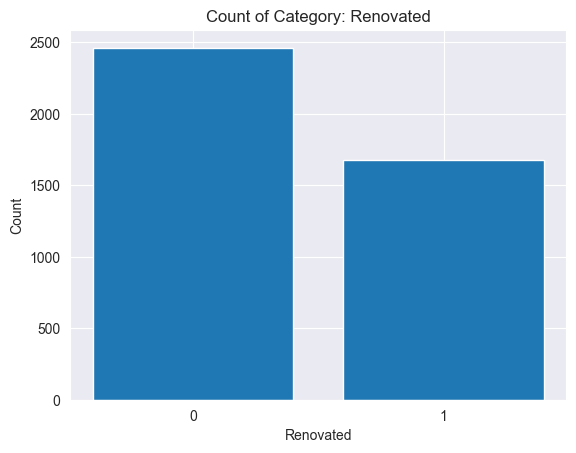

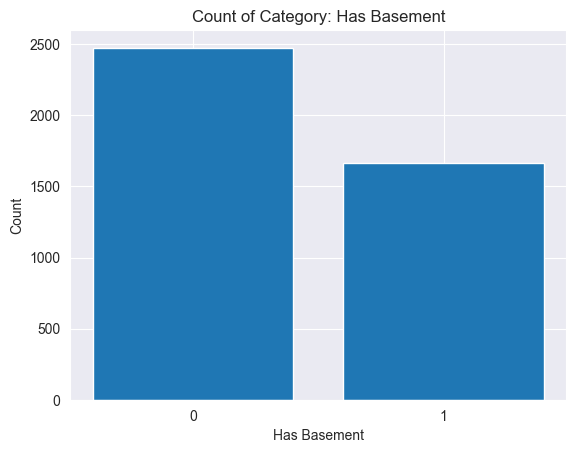

In [41]:
import matplotlib.pyplot as plt

#counting all categorical values per category
bedrooms_count = housing_ds["bedrooms"].value_counts()
floors_count = housing_ds["floors"].value_counts()
waterfront_count = housing_ds["waterfront"].value_counts()
view_count = housing_ds["view"].value_counts()
condition_count = housing_ds["condition"].value_counts()
renovated_count = housing_ds["renovated"].value_counts()
has_basement_count = housing_ds["has_basement"].value_counts()
city_count = housing_ds["city"].value_counts()
statezip_count = housing_ds["statezip"].value_counts()

def categorical_eda_plot(ds, category_name):
    plt.figure()
    plt.bar(ds.index.astype(str), ds.values)
    plt.title("Count of Category: " + category_name)
    plt.xlabel(category_name)
    plt.ylabel("Count")
    plt.show()

categorical_eda_plot(bedrooms_count, "Number of Bedrooms")
categorical_eda_plot(floors_count, "Number of Floors")
categorical_eda_plot(waterfront_count, "Waterfront")
categorical_eda_plot(view_count, "View")
categorical_eda_plot(condition_count, "Condition")
categorical_eda_plot(renovated_count, "Renovated")
categorical_eda_plot(has_basement_count, "Has Basement")

In [42]:
print("Houses sold per city:")
print(city_count)
print("Houses sold per zip code:")
print(statezip_count)

Houses sold per city:
city
Seattle               1415
Renton                 261
Bellevue               260
Redmond                209
Kent                   167
Kirkland               166
Issaquah               162
Auburn                 162
Sammamish              158
Federal Way            131
Shoreline              112
Woodinville            103
Maple Valley            90
Mercer Island           81
Snoqualmie              65
Burien                  64
Kenmore                 58
Des Moines              52
North Bend              45
Duvall                  39
Covington               39
Lake Forest Park        33
Newcastle               31
Bothell                 30
SeaTac                  29
Vashon                  28
Tukwila                 28
Enumclaw                28
Carnation               18
Normandy Park           16
Medina                  11
Clyde Hill              10
Fall City                9
Black Diamond            7
Pacific                  6
Yarrow Point             4
R

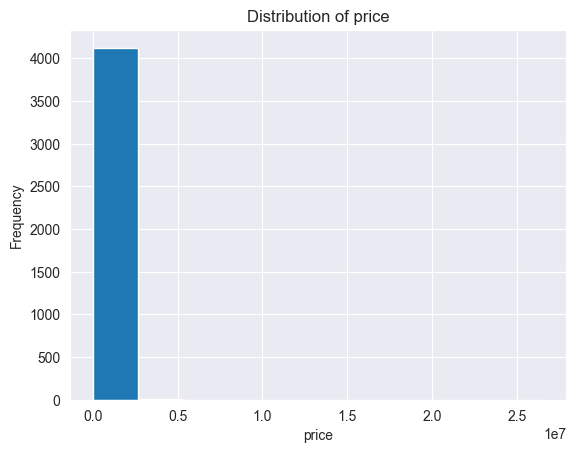

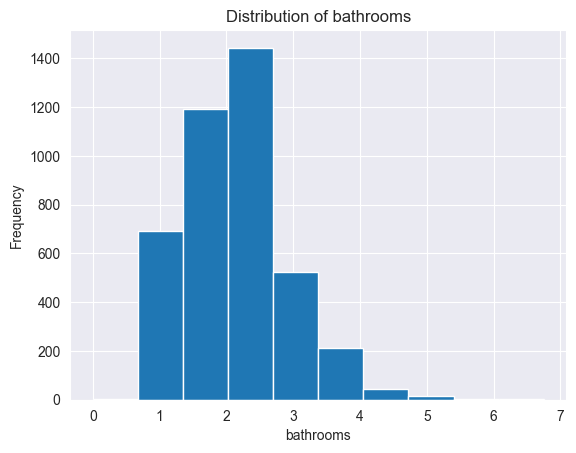

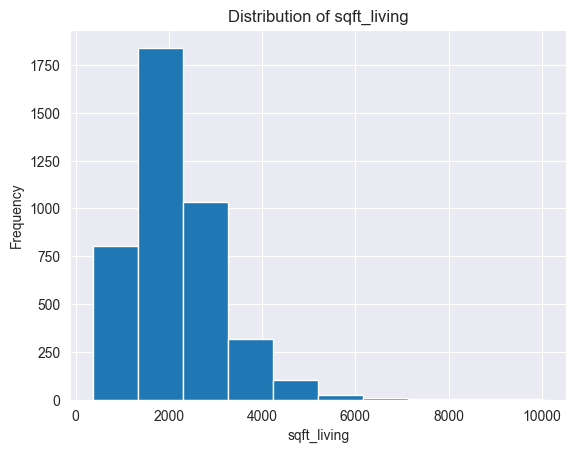

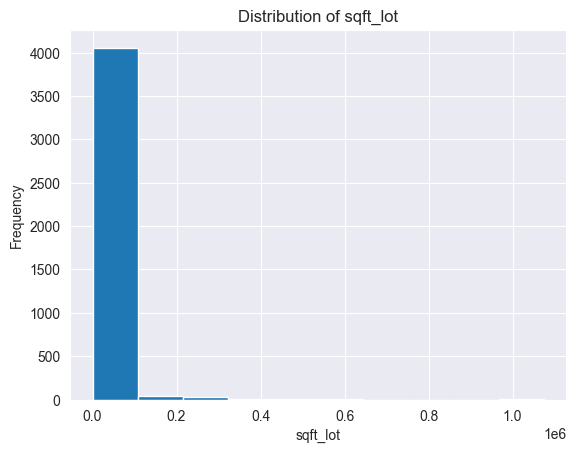

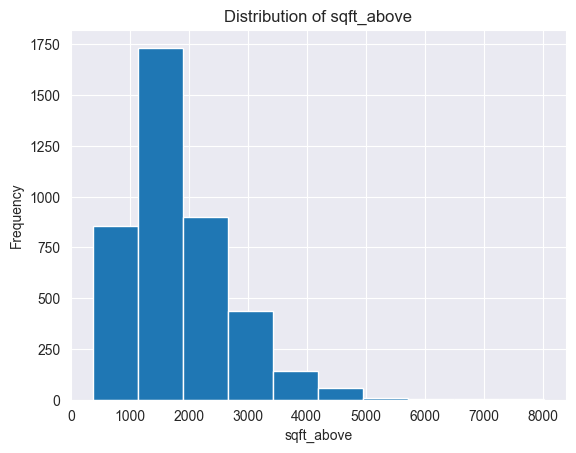

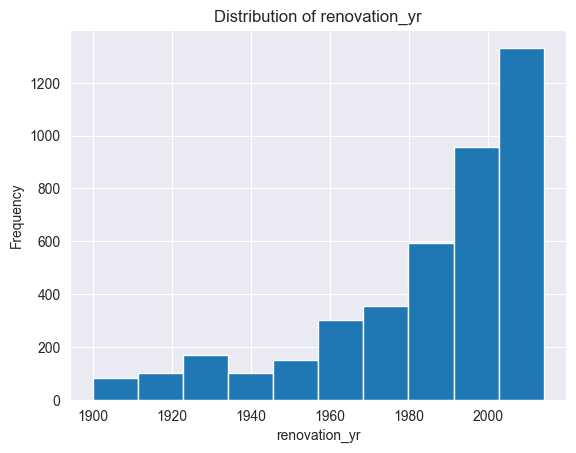

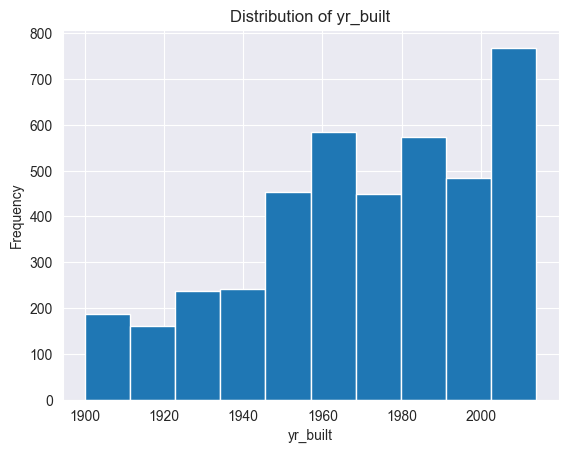

In [43]:
#list of numerical columns
numericals = ["price","bathrooms","sqft_living","sqft_lot","sqft_above","renovation_yr","yr_built"]

def numerical_eda_plot(ds, column):
    plt.figure()
    plt.hist(ds[column], bins=10)
    plt.title("Distribution of " + column)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

for column in numericals:
    numerical_eda_plot(housing_ds, column)

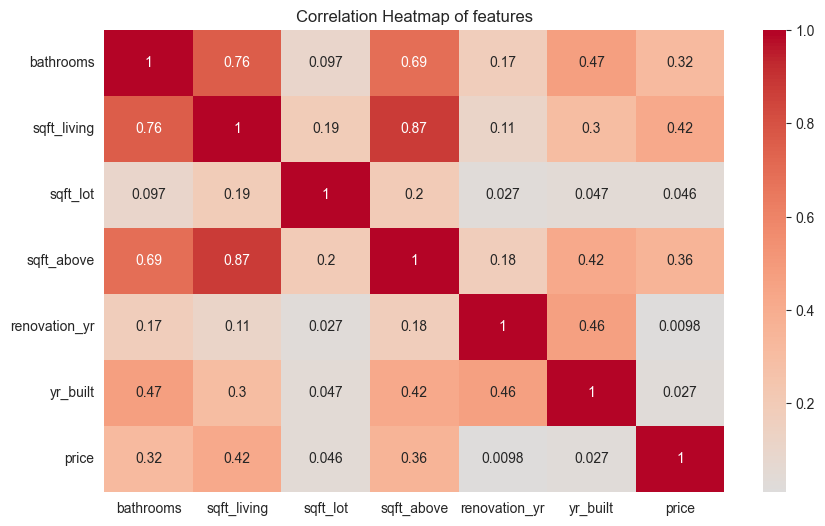

In [44]:
import seaborn as sb
#correlation heatmaps:

#lists of numericals without price (target)
numericals_without_price = ["bathrooms","sqft_living","sqft_lot","sqft_above","renovation_yr","yr_built"]

corr_matrix = housing_ds[numericals_without_price + ["price"]].corr()
plt.figure(figsize=(10,6))
sb.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of features")
plt.show()




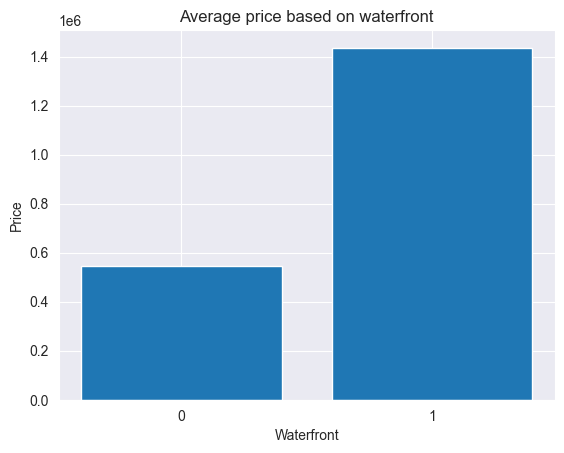

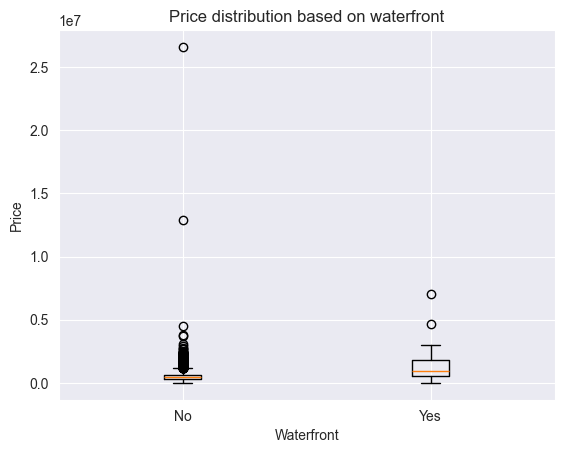

In [45]:
#trying to find if waterfront column affects price
mean_price_based_on_waterfront = housing_ds.groupby("waterfront")["price"].mean()

plt.figure()
plt.bar(mean_price_based_on_waterfront.index.astype(str), mean_price_based_on_waterfront.values)
plt.title("Average price based on waterfront")
plt.xlabel("Waterfront")
plt.ylabel("Price")
plt.show()

# splitting dataset based on waterfront
no_waterfront = housing_ds[housing_ds["waterfront"]==0]["price"]
yes_waterfront = housing_ds[housing_ds["waterfront"]==1]["price"]

plt.figure()
plt.boxplot([no_waterfront, yes_waterfront])
plt.xticks([1,2],["No","Yes"])
plt.title("Price distribution based on waterfront")
plt.xlabel("Waterfront")
plt.ylabel("Price")
plt.show()

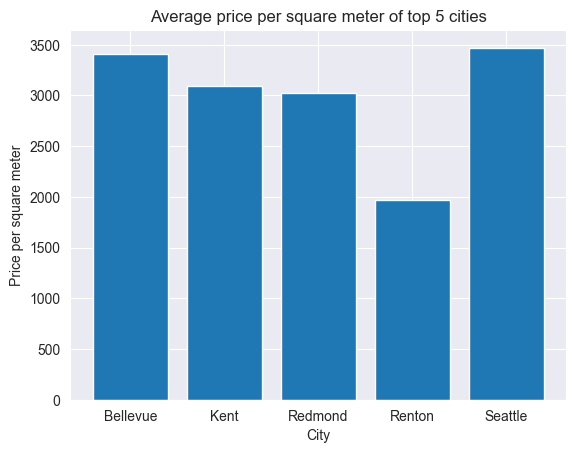

In [46]:
# to calculate the price per square meter, sqft_living column will be used
# since it's the sum of sqft_above + sqft_basement
# so the square feet should be converted to square meters
# conversion rate of sqft to sqm = 0.092903
sqft_to_sqm = 0.092903
housing_ds["price_per_sqm"] = housing_ds["price"]/(housing_ds["sqft_living"]*sqft_to_sqm)

# based on previous analysis below are the top 5 cities based on sales
# Seattle               1415
# Renton                 261
# Bellevue               260
# Redmond                209
# Kent                   167

records_of_top5_cities = housing_ds[(housing_ds["city"]=="Seattle") | (housing_ds["city"]== "Renton") | (housing_ds["city"] == "Bellevue") | (housing_ds["city"] == "Redmond") | (housing_ds["city"] == "Kent")]

#grouping top 5 cities based on price per sqm
mean_of_top5_city_prices = records_of_top5_cities.groupby("city")["price_per_sqm"].mean()

plt.figure()
plt.bar(mean_of_top5_city_prices.index.astype(str), mean_of_top5_city_prices.values)
plt.title("Average price per square meter of top 5 cities")
plt.xlabel("City")
plt.ylabel("Price per square meter")
plt.show()

-2409.7597633831083
7743.672663243189
Lower quantile: 1941.7112765995905
Upper quantile: 3392.20162326049


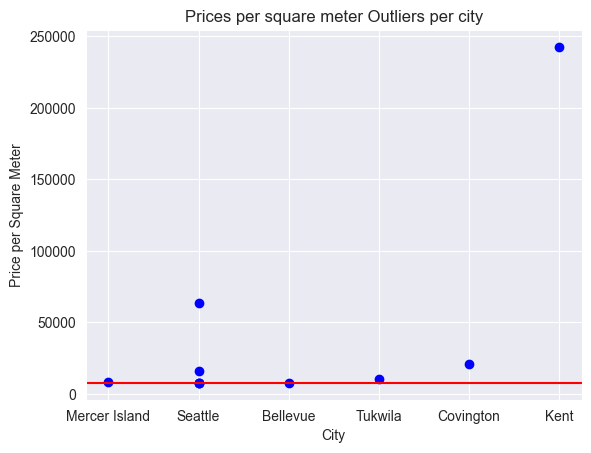

In [47]:
#Extreme values on price
q1 = housing_ds["price_per_sqm"].quantile(0.25)
q3 = housing_ds["price_per_sqm"].quantile(0.75)
IQR = q3 - q1
lower = q1 - 3 * IQR
upper = q3 + 3 * IQR
print(f"{lower}\n{upper}")
outliers = housing_ds[(housing_ds["price_per_sqm"] < lower) | (housing_ds["price_per_sqm"] > upper)]
print (f"Lower quantile: {q1}\nUpper quantile: {q3}")
#creating the scatterplot that shows each values, having a line on the upper limit.
plt.scatter(outliers["city"],outliers["price_per_sqm"] , color='blue', marker='o')
plt.ylabel('Price per Square Meter')
plt.xlabel('City')
plt.title('Prices per square meter Outliers per city')
plt.axhline(y=upper, color='r', linestyle='-', label='Upper Bound Extremes')
plt.show()

-1980.0
6070.0
Lower quantile: 1470.0
Upper quantile: 2620.0


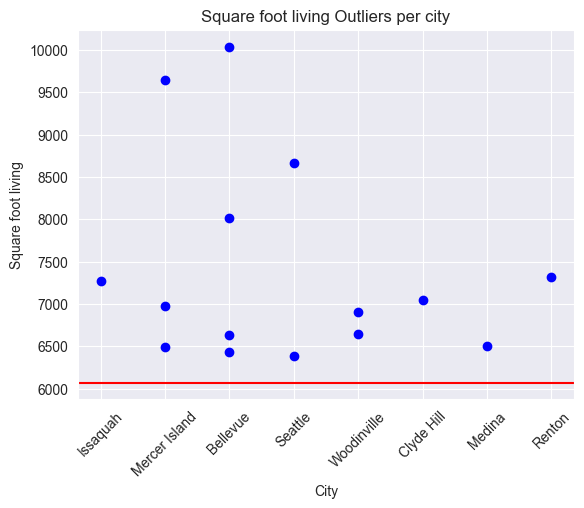

In [48]:
#Extreme values
q1 = housing_ds["sqft_living"].quantile(0.25)
q3 = housing_ds["sqft_living"].quantile(0.75)
IQR = q3 - q1
lower = q1 - 3 * IQR
upper = q3 + 3 * IQR
print(f"{lower}\n{upper}")
outliers = housing_ds[(housing_ds["sqft_living"] < lower) | (housing_ds["sqft_living"] > upper)]
print (f"Lower quantile: {q1}\nUpper quantile: {q3}")
#creating the scatterplot that shows each values, having a line on the upper limit.
plt.scatter(outliers["city"],outliers["sqft_living"] , color='blue', marker='o')
plt.ylabel('Square foot living')
plt.xlabel('City')
plt.title('Square foot living Outliers per city')
plt.xticks(rotation=45)
plt.axhline(y=upper, color='r', linestyle='-', label='Upper Bound Extremes')
plt.show()

0.0
7.0
Lower quantile: 3.0
Upper quantile: 4.0


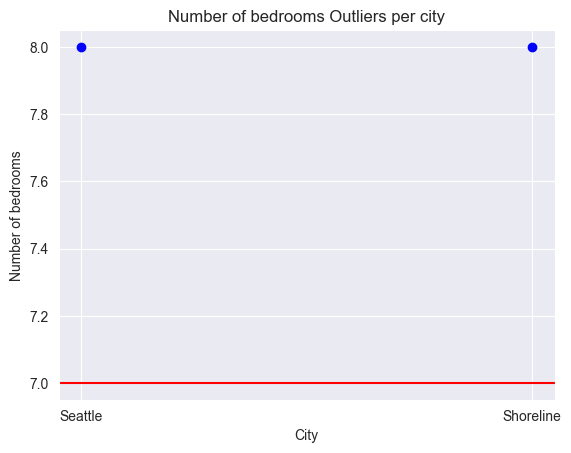

In [49]:
#Extreme values
q1 = housing_ds["bedrooms"].quantile(0.25)
q3 = housing_ds["bedrooms"].quantile(0.75)
IQR = q3 - q1
lower = q1 - 3 * IQR
upper = q3 + 3 * IQR
print(f"{lower}\n{upper}")
outliers = housing_ds[(housing_ds["bedrooms"] < lower) | (housing_ds["bedrooms"] > upper)]
print (f"Lower quantile: {q1}\nUpper quantile: {q3}")
#creating the scatterplot that shows each values, having a line on the upper limit.
plt.scatter(outliers["city"],outliers["bedrooms"] , color='blue', marker='o')
plt.ylabel('Number of bedrooms')
plt.xlabel('City')
plt.title('Number of bedrooms Outliers per city')
plt.axhline(y=upper, color='r', linestyle='-', label='Upper Bound Extremes')
plt.show()

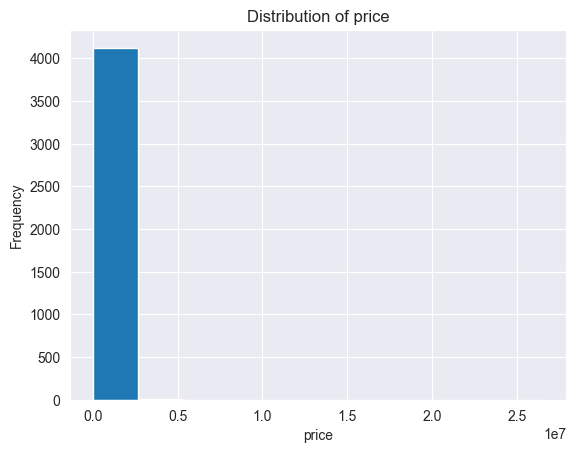

Mean of price per months for all cities:
month
5    530924.573527
6    547968.179909
7    614407.818959
Name: price, dtype: float64
Mean of price per months for Seattle:
month
5    544061.053910
6    588321.076909
7    614443.026992
Name: price, dtype: float64


<Axes: xlabel='month'>

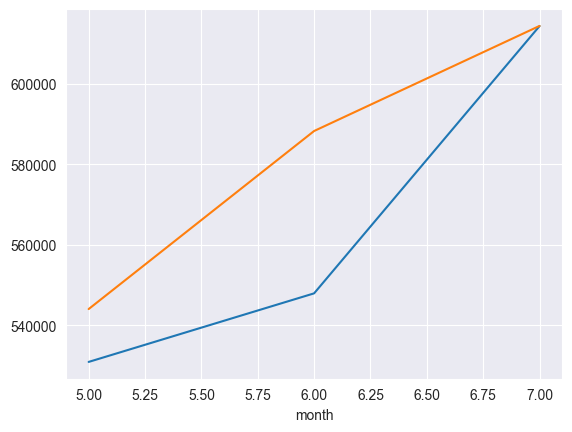

In [50]:
# removing maximum prie since it seems to be an extreme value with potential to worsen the remaining processes.

housing_ds = housing_ds[(housing_ds["price"]!=26590000) | (housing_ds["price"]>0)]
numerical_eda_plot(housing_ds, "price")

#proceeding to calculate the mean of each house price and then of each house price for Seattle - the town with most sales
months_mean = housing_ds.groupby("month")["price"].mean()
print('Mean of price per months for all cities:')
print(months_mean)
housing_ds.groupby("month")["price"].mean().plot(kind='line')

#for seattle:
seattle_mean = housing_ds[housing_ds["city"]=='Seattle'].groupby("month")["price"].mean()
print('Mean of price per months for Seattle:')
print(seattle_mean)
housing_ds[housing_ds["city"]=='Seattle'].groupby("month")["price"].mean().plot(kind='line')


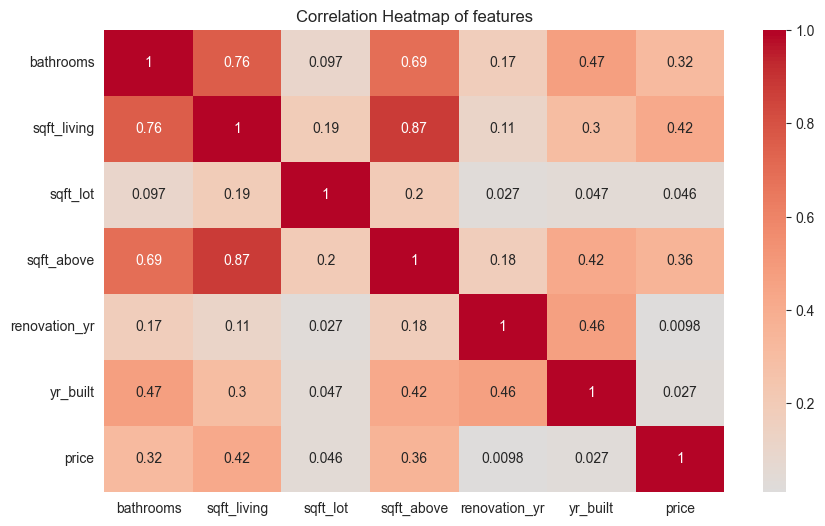

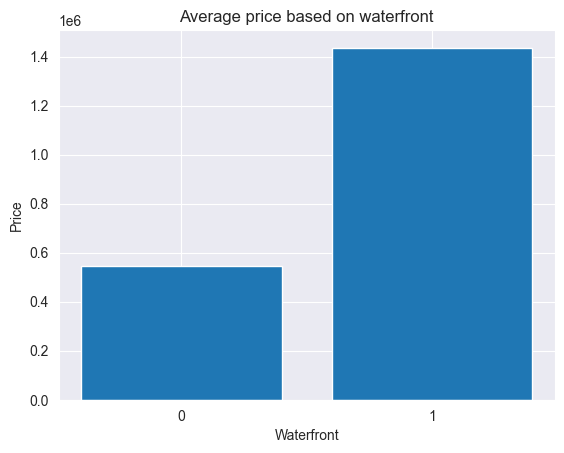

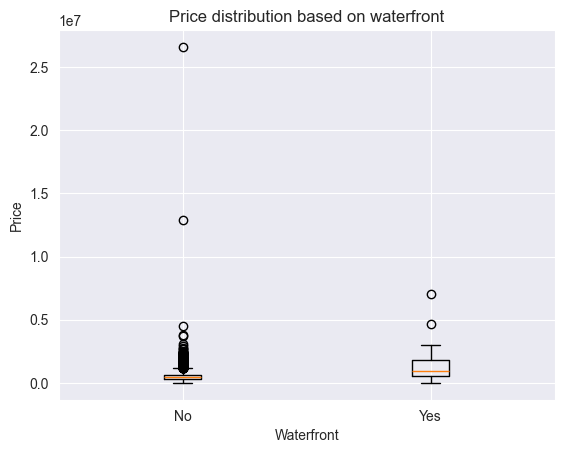

In [51]:
# recreating a few graphs after removal of extreme value

# correlation heatmap
corr_matrix = housing_ds[numericals_without_price + ["price"]].corr()
plt.figure(figsize=(10,6))
sb.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of features")
plt.show()

# bar chart of average price based on waterfront
plt.figure()
plt.bar(mean_price_based_on_waterfront.index.astype(str), mean_price_based_on_waterfront.values)
plt.title("Average price based on waterfront")
plt.xlabel("Waterfront")
plt.ylabel("Price")
plt.show()

#box plot
plt.figure()
plt.boxplot([no_waterfront, yes_waterfront])
plt.xticks([1,2],["No","Yes"])
plt.title("Price distribution based on waterfront")
plt.xlabel("Waterfront")
plt.ylabel("Price")
plt.show()

Number of groups based on Sturges Rule: 14
Each bin has the following width: 690.71
Bivariate Frequency Table (Counts)
condition             1   2     3     4    5  Total
sqft_bins                                          
(360.33, 1060.714]    2   9   191   117   39    358
(1060.714, 1751.429]  1  10   788   358  108   1265
(1751.429, 2442.143]  2   6   713   372  138   1231
(2442.143, 3132.857]  0   1   486   167   68    722
(3132.857, 3823.571]  0   0   241    62   30    333
(3823.571, 4514.286]  0   0   114    20    9    143
(4514.286, 5205.0]    0   0    33     8    6     47
(5205.0, 5895.714]    0   1    13     6    0     20
(5895.714, 6586.429]  0   0     9     1    0     10
(6586.429, 7277.143]  0   0     3     3    0      6
(7277.143, 7967.857]  0   0     1     0    0      1
(7967.857, 8658.571]  0   0     1     0    0      1
(8658.571, 9349.286]  0   0     1     0    0      1
(9349.286, 10040.0]   0   0     2     0    0      2
Total                 5  27  2596  1114  398   41

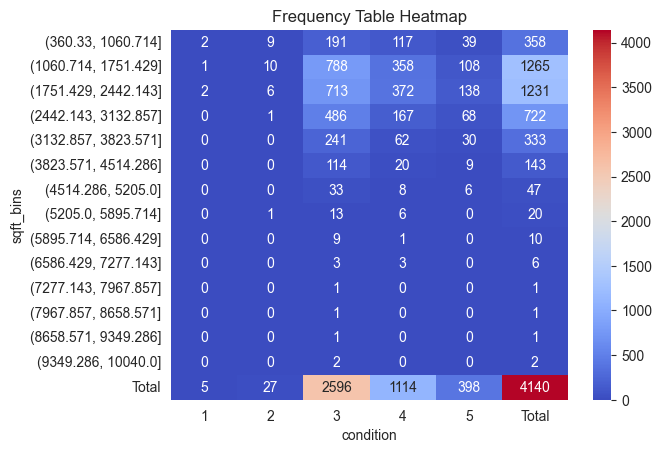

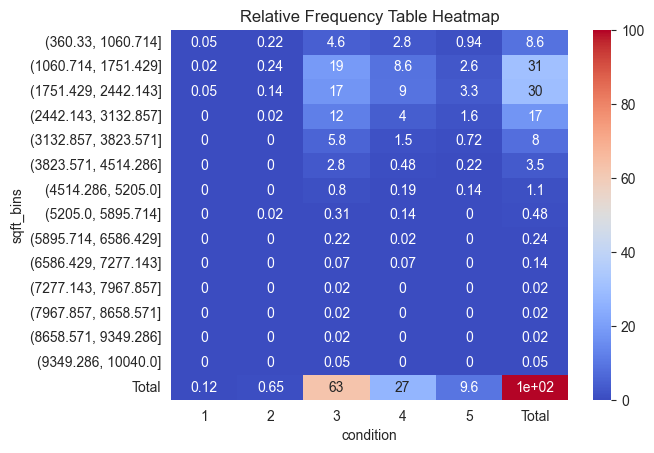

In [52]:
# how does size affect price?
# calculating number of classes using Sturges Rule and
# then grouping based on price ranges and condition (categorical) - which is also a big driving point of the price
import math

#length of dataset to be used by Sturges rule
dataset_length = len(housing_ds)
#Sturges rule rounded
k = math.ceil(1 + 3.322 * math.log10(dataset_length))
print(f"Number of groups based on Sturges Rule: {k}")
#calculating width of each bin for each sqft_living value
sqft_living_min = housing_ds['sqft_living'].min()
sqft_living_max = housing_ds['sqft_living'].max()

h = round((sqft_living_max - sqft_living_min)/k,2)
print(f"Each bin has the following width: {h}")

housing_ds["sqft_bins"] = pd.cut(housing_ds["sqft_living"], k)
# print(housing_ds["sqft_bins"].head()) #for debugging

#creating frequency table, setting index to the size bins that were previously set, columns will be the conditions of each house (1 to 5), margins will be true to show the Total column and row
frequency_table = pd.crosstab(
    index=housing_ds["sqft_bins"],
    columns=housing_ds["condition"],
    margins=True,
    margins_name = "Total"
)
#crating the frequency table
relative_frequency = frequency_table / dataset_length
#bivariate frequency table
print("Bivariate Frequency Table (Counts)")
print(frequency_table)
# relative bivariate frequency table
print("Relative Frequency Table (%)")
print(relative_frequency.round(4) * 100)
# hatmap of both tables
sb.heatmap(frequency_table, annot=True, fmt="d", cmap="coolwarm")
plt.title("Frequency Table Heatmap")
plt.show()

sb.heatmap(relative_frequency.round(4) * 100, annot=True, cmap="coolwarm")
plt.title("Relative Frequency Table Heatmap")
plt.show()


--- Bivariate Frequency Table (Counts) ---
condition             1   2     3     4    5  Total
sqft_bins_of_7                                     
(360.33, 1751.429]    3  19   979   475  147   1623
(1751.429, 3132.857]  2   7  1199   539  206   1953
(3132.857, 4514.286]  0   0   355    82   39    476
(4514.286, 5895.714]  0   1    46    14    6     67
(5895.714, 7277.143]  0   0    12     4    0     16
(7277.143, 8658.571]  0   0     2     0    0      2
(8658.571, 10040.0]   0   0     3     0    0      3
Total                 5  27  2596  1114  398   4140

--- Relative Frequency Table (%) ---
condition                1     2      3      4     5   Total
sqft_bins_of_7                                              
(360.33, 1751.429]    0.07  0.46  23.65  11.47  3.55   39.20
(1751.429, 3132.857]  0.05  0.17  28.96  13.02  4.98   47.17
(3132.857, 4514.286]  0.00  0.00   8.57   1.98  0.94   11.50
(4514.286, 5895.714]  0.00  0.02   1.11   0.34  0.14    1.62
(5895.714, 7277.143]  0.00  0.00

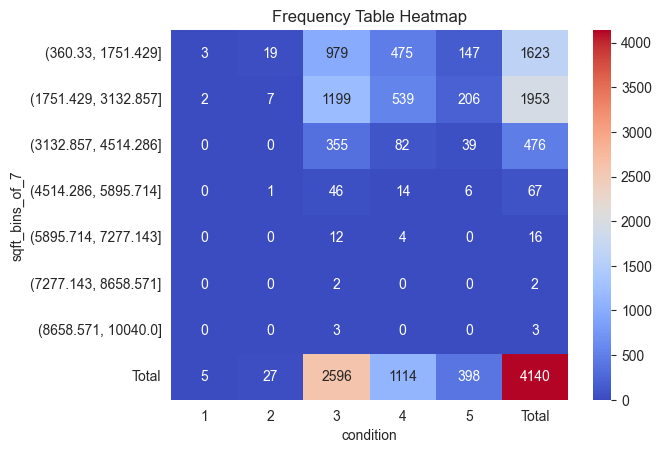

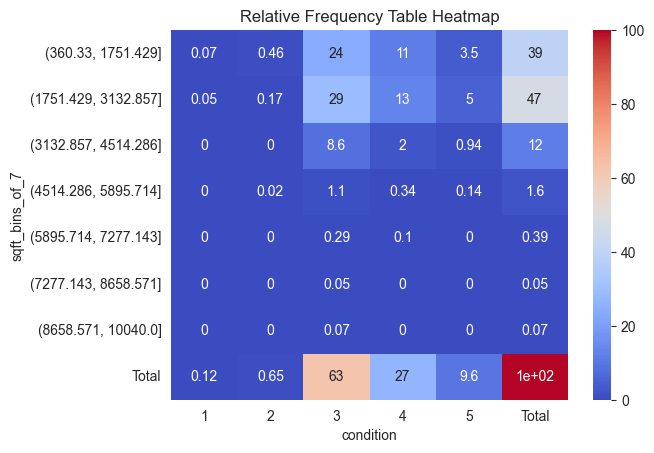

In [53]:
# using 7 bins instead of Sturges rule
h_for_seven_bins = round((sqft_living_max - sqft_living_min)/7,2)

housing_ds["sqft_bins_of_7"] = pd.cut(housing_ds["sqft_living"], 7)
frequency_table_7_bins = pd.crosstab(
    index=housing_ds["sqft_bins_of_7"],
    columns=housing_ds["condition"],
    margins=True,
    margins_name = "Total"

)

relative_frequency_7_bins = frequency_table_7_bins / dataset_length

print("\n--- Bivariate Frequency Table (Counts) ---")
print(frequency_table_7_bins)

print("\n--- Relative Frequency Table (%) ---")
print(relative_frequency_7_bins.round(4) * 100)

sb.heatmap(frequency_table_7_bins, annot=True, fmt="d", cmap="coolwarm")
plt.title("Frequency Table Heatmap")
plt.show()

sb.heatmap(relative_frequency_7_bins.round(4) * 100, annot=True, cmap="coolwarm")
plt.title("Relative Frequency Table Heatmap")
plt.show()

In [54]:
#finding price means per bin, to see correlation and mean per bin
average_price_per_bin = housing_ds.groupby('sqft_bins')['price'].mean()
count = 0
for record in average_price_per_bin:
    print(f'Average price for bin of {average_price_per_bin.index[count]} : {record:,.2f}')
    count += 1
# print(f'{average_price_per_bin}')

Average price for bin of (360.33, 1060.714] : 297,270.40
Average price for bin of (1060.714, 1751.429] : 407,840.53
Average price for bin of (1751.429, 2442.143] : 497,975.15
Average price for bin of (2442.143, 3132.857] : 656,512.17
Average price for bin of (3132.857, 3823.571] : 854,119.91
Average price for bin of (3823.571, 4514.286] : 1,098,388.57
Average price for bin of (4514.286, 5205.0] : 1,277,554.34
Average price for bin of (5205.0, 5895.714] : 1,509,550.00
Average price for bin of (5895.714, 6586.429] : 1,951,485.00
Average price for bin of (6586.429, 7277.143] : 2,222,314.67
Average price for bin of (7277.143, 7967.857] : 1,135,250.00
Average price for bin of (7967.857, 8658.571] : 0.00
Average price for bin of (8658.571, 9349.286] : 2,888,000.00
Average price for bin of (9349.286, 10040.0] : 5,865,250.00


In [55]:
# same but with 7 bins
average_price_per_bin = housing_ds.groupby('sqft_bins_of_7')['price'].mean()
count = 0
for record in average_price_per_bin:
    print(f'Average price for bin of {average_price_per_bin.index[count]} : {record:,.2f}')
    count += 1
# print(f'{average_price_per_bin}')

Average price for bin of (360.33, 1751.429] : 383,451.06
Average price for bin of (1751.429, 3132.857] : 556,584.33
Average price for bin of (3132.857, 4514.286] : 927,503.14
Average price for bin of (4514.286, 5895.714] : 1,346,806.78
Average price for bin of (5895.714, 7277.143] : 2,053,046.12
Average price for bin of (7277.143, 8658.571] : 567,625.00
Average price for bin of (8658.571, 10040.0] : 4,872,833.33


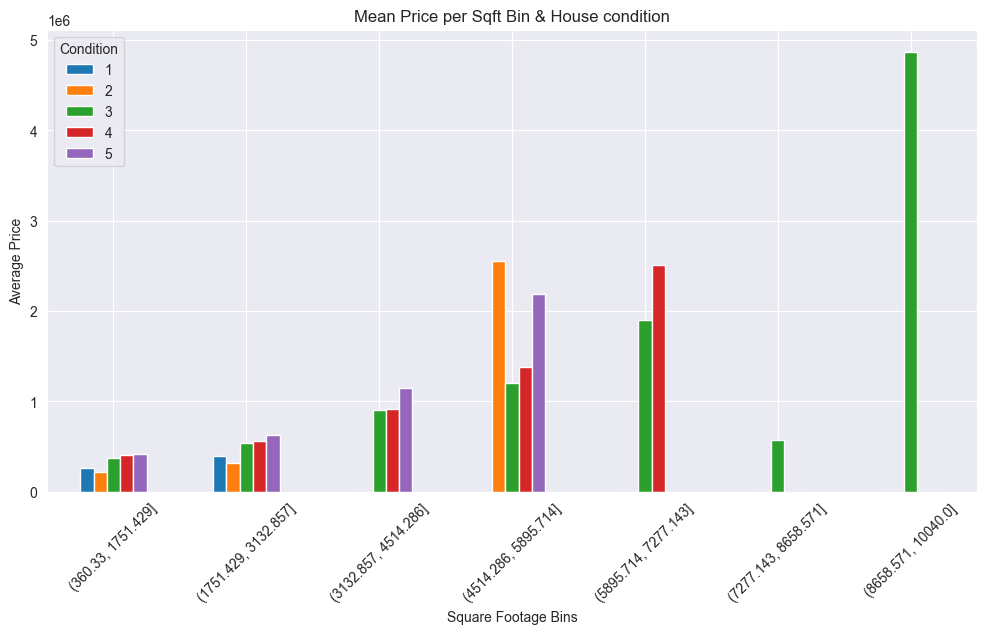

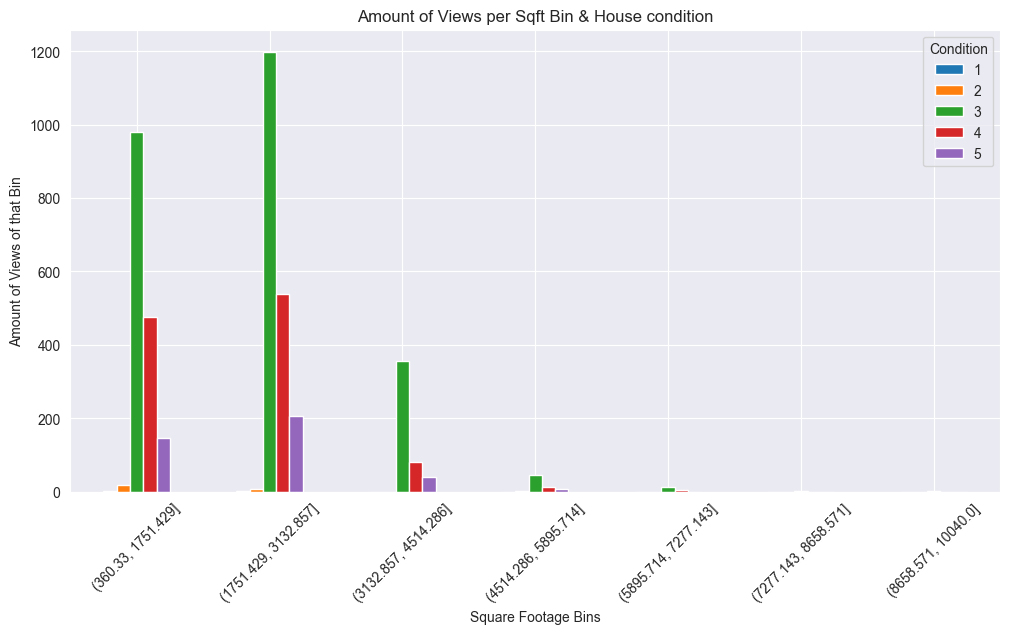

In [56]:
# based on above table, getting the mean of each group, grouping by bin and condition for 7 bins, which will result in 7 * 5 = 35 groups

housing_ds_group_mean = housing_ds.groupby(["sqft_bins_of_7","condition"])["price"].mean()
# print(housing_ds_group_mean) # for debugging

#unstack makes data to wide format
housing_ds_group_mean.unstack().plot(kind='bar', figsize=(12, 6))

# showing average price per group
plt.title("Mean Price per Sqft Bin & House condition")
plt.ylabel("Average Price")
plt.xlabel("Square Footage Bins")
plt.legend(title="Condition")
plt.xticks(rotation=45)
plt.show()

#same for views instead of price
housing_ds_group_view_mean = housing_ds.groupby(["sqft_bins_of_7","condition"])["view"].count()
housing_ds_group_view_mean.unstack().plot(kind='bar', figsize=(12, 6))
# showing average views per group
plt.title("Amount of Views per Sqft Bin & House condition")
plt.ylabel("Amount of Views of that Bin")
plt.xlabel("Square Footage Bins")
plt.legend(title="Condition")
plt.xticks(rotation=45)
plt.show()

In [58]:
# before proceeding with the application of ML and DL, one-hot encoding will be applied to categorical data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# one-hot encoding for city
updated_housing_ds = housing_ds.drop('city', axis=1).join(pd.get_dummies(housing_ds['city']))

# print(numericals)
# print(updated_housing_ds.columns)

numericals_for_regr = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors','view','condition','sqft_above', 'renovation_yr', 'yr_built']

#features
x = updated_housing_ds.drop(['price','date', 'sqft_basement', 'street', 'statezip', 'country', 'price_per_sqm', 'sqft_bins', 'sqft_bins_of_7','yr_built','sqft_above'], axis=1)

#target
y = updated_housing_ds['price']

#split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
# preperation of scaler to normalize the data
scaler = StandardScaler()
x_train[numericals_for_regr] = scaler.fit_transform(x_train[numericals_for_regr])
x_test[numericals_for_regr] = scaler.transform(x_test[numericals_for_regr])

# to prevent errors from potential type missmatches
x_train = np.array(x_train).astype(float)
x_test = np.array(x_test).astype(float)

model = LinearRegression()
model.fit(x_train, y_train)

y_predict = model.predict(x_test)

print(f"Mean Absolute Error: ${mean_absolute_error(y_test, y_predict):,.2f}")
print(f"Mean Squared Error: ${mean_squared_error(y_test, y_predict):,.2f}")
print(f"R2 Score: {r2_score(y_test, y_predict):,.2f}")

# Mean Absolute Error: $134,262.44
# Root Mean Squared Error: $71,855,706,266.59
# Mean absolute percentage error: 29,154,221,913,720,692,736.00

Mean Absolute Error: $139,994.12
Mean Squared Error: $55,944,899,803.61
R2 Score: 0.47


In [36]:
# LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# x_train and x_test are already scaled
x_train_lstm = x_train.reshape((x_train.shape[0], 1, x_train.shape[1]))
x_test_lstm = x_test.reshape((x_test.shape[0], 1, x_test.shape[1]))

model = Sequential([
    #high number of memory cells to help with complex patterns (with risk of overfitting)
    LSTM(500, input_shape=(x_train_lstm.shape[1], x_train_lstm.shape[2]), return_sequences=True),
    LSTM(250),
    #takes the output from LSTM and looks for non-linear relationships using relu
    Dense(100, activation='relu'),
    #helps with potential overfitting from above memory cells
    Dropout(0.2),
    Dense(1) # Single output for 'price'
])

#implementation of early stopping to prevent cycles of no improvement
early_stopping = EarlyStopping(
    monitor='val_loss',     # watch the validation loss
    patience=10,            # stop after 10 epochs of no improvement
    restore_best_weights=True, # do a roll-back to the best weights found
    verbose=1
)

# using mean square error to measure loss
model.compile(optimizer='adam', loss='mse')
model.fit(x_train_lstm, y_train, epochs=100, batch_size=32, validation_split=0.1,callbacks=[early_stopping], verbose=1)

lstm_preds = model.predict(x_test_lstm)

print(f"Mean Absolute Error: ${mean_absolute_error(y_test, y_predict):,.2f}")
print(f"Mean Squared Error: ${mean_squared_error(y_test, y_predict):,.2f}")
print(f"R2 Score: {r2_score(y_test, y_predict):,.2f}")

C:\Users\chris\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 501273067520.0000 - val_loss: 2576793993216.0000
Epoch 2/100
27/94 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 447923461233.7778

KeyboardInterrupt: 

In [37]:
# !pip install statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor

# checking VIF on the numerical features only
def vif_and_print(dataframe):
    vif_data = pd.DataFrame()
    vif_features = dataframe
    vif_data["feature"] = vif_features.columns

    # calculating VIF for each feature
    vif_data["VIF"] = [variance_inflation_factor(vif_features.values, i)
                       for i in range(len(vif_features.columns))]

    print(vif_data.sort_values(by="VIF", ascending=False))

vif_and_print(updated_housing_ds[numericals_for_regr])

         feature          VIF
9       yr_built  5675.052156
8  renovation_yr  5342.367166
2    sqft_living    47.684304
7     sqft_above    34.780647
6      condition    29.125481
1      bathrooms    26.326791
0       bedrooms    24.883902
4         floors    16.741062
5           view     1.313183
3       sqft_lot     1.245296
